# Independent cross-check: Ames Stereo Pipeline `sfs` vs. our own Hapke hillshade

`lunaserv.hapke_shade_ortho` is our own hand-rolled pipeline: `_terrain_photometric_angles`
(per-pixel incidence/emission/phase, computed directly in Python) feeds ISIS `photomet`'s Hapke
evaluator, and the result relights the WAC_EMP ortho texture by the ratio H(i,e,g)/H(reference).

This notebook runs an independent check instead of another variation on that same pipeline: Ames
Stereo Pipeline's `sfs` tool, used purely as a forward renderer (`--save-sim-intensity-only`, no
DEM refinement) -- its own ray-DEM intersection, its own Hapke reflectance implementation, given
the same DEM and the same ISIS-calibration-sourced Hapke parameters, and a "true albedo" map built
by undoing the same reference-geometry normalization `hapke_shade_ortho` itself undoes
(`sfs_validation.true_albedo_map`). If the two independently-coded pipelines agree given the same
inputs, that's evidence neither is broken.

**Caveats, from `sfs_validation.py`'s own module docstring:**
- ASP's `sfs --model-coeffs` Hapke parameterization (`omega, b, c, B0, h`) has no equivalent to
  ISIS `HAPKEHEN`'s `theta` (macroscopic roughness) -- silently dropped, a permanent gap in this
  cross-check.
- `sfs` refuses the real WAC crop's own native ISIS Pushframe camera outright ("Seems to have Isis
  camera type 1... Maybe it will work with CSM"). This uses our own reconstructed CSM camera
  instead (the same one `hapke_shade_ortho` itself renders from, independently validated against
  `campt` to ~0.018 deg) -- a different source of camera-pose truth than the real WAC crop's own
  camera, not an approximation of unknown quality.
- `sfs`'s own simulated-intensity coverage is smaller than the padded DEM/ortho AOI (only the
  camera's own FOV, ~28-32% of the AOI for the candidate this notebook uses by default) --
  `sfs_validation.mask_sfs_uncovered` converts `sfs`'s own literal-`0.0` "outside coverage"
  convention to `nodata` before any brightness comparison, or the comparison is dominated by that
  region instead of signal.

In [1]:
import numpy as np
import rasterio

import trntest
from trntest import illumination, lunaserv, plotting, sfs_validation
from trntest.plotting import compute_brightness_matched_diff

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
camera = entry.camera
config = entry.per_image_config

print(f"EDR product: {entry.edr_product}")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

EDR product: M1327210646CE
Ground footprint center (lon, lat): (np.float64(169.57486295387), np.float64(38.762076131300994))


## Run the forward render

`entry.dem_ortho_result` is the current default basemap (resumed from disk if
`image_generation.ipynb` already generated it for this manifest entry, fetched fresh otherwise).
`sfs_validation.run_sfs_forward_render` builds the true-albedo map and the Hapke `--model-coeffs`
string from it, then runs `sfs -i <dem> --reflectance-type 2 --model-coeffs ...
--input-albedo ... --save-sim-intensity-only <our own CSM-attached camera cube>`.

In [2]:
dem_ortho_result = entry.dem_ortho_result
sfs_result = sfs_validation.run_sfs_forward_render(camera, dem_ortho_result, config)

print("model_coeffs (omega b c B0 h):", sfs_result.model_coeffs)
print("dropped theta (macroscopic roughness, deg):", sfs_result.hapkehen_params["theta"])
print("sim_intensity_tif:", sfs_result.sim_intensity_tif)

model_coeffs (omega b c B0 h): 0.39262253046035767 0.22359317541122437 0.47049668431282043 1.649500846862793 0.044595811516046524
dropped theta (macroscopic roughness, deg): 23.656600952148438
sim_intensity_tif: /workspace/output/trn_dataset/_work/M1327210646CE/sfs_validation/sfs_run/run-sfs_camera-sim-intensity.tif


## Mask sfs's "outside coverage" pixels, then compare against the real WAC crop

`entry.crop._mapprojected_path()` is the ISIS-processed WAC crop reprojected onto this same local
Orthographic CRS (`isis_wac.run_cam2map_for_crop`) -- the same ground-truth image
`image_generation.ipynb`'s own blink comparisons use.

In [3]:
sim_masked_path = sfs_result.sim_intensity_tif.parent / "sim-intensity-masked.tif"
sfs_validation.mask_sfs_uncovered(sfs_result.sim_intensity_tif, sim_masked_path)

real_wac_mapproj_path = entry.crop._mapprojected_path()  # noqa: SLF001 -- notebook-side use

diff_vs_sfs = compute_brightness_matched_diff(real_wac_mapproj_path, sim_masked_path)
diff_vs_ours = compute_brightness_matched_diff(real_wac_mapproj_path, dem_ortho_result.ortho)
print("brightness-matched diff, real WAC vs. our hillshade:      ", diff_vs_ours)
print("brightness-matched diff, real WAC vs. sfs forward-render: ", diff_vs_sfs)

brightness-matched diff, real WAC vs. our hillshade:       BrightnessMatchedDiffResult(mean_abs_diff=0.0038214798610083527, median_abs_diff=0.0030211172997951508, valid_pixel_count=2205021)
brightness-matched diff, real WAC vs. sfs forward-render:  BrightnessMatchedDiffResult(mean_abs_diff=0.005444582426541483, median_abs_diff=0.004383851108142649, valid_pixel_count=1618385)


## Visual comparison

All three panels brightness-matched to the real WAC panel (single multiplicative median scale, not
an affine/percentile stretch -- see `plotting.compute_brightness_matched_diff`'s own docstring for
why). Look for whether `sfs`'s independent render agrees with the real WAC crop about as well as
our own hillshade does, and whether any disagreement looks like a structured geometric or
photometric effect rather than uniform noise.

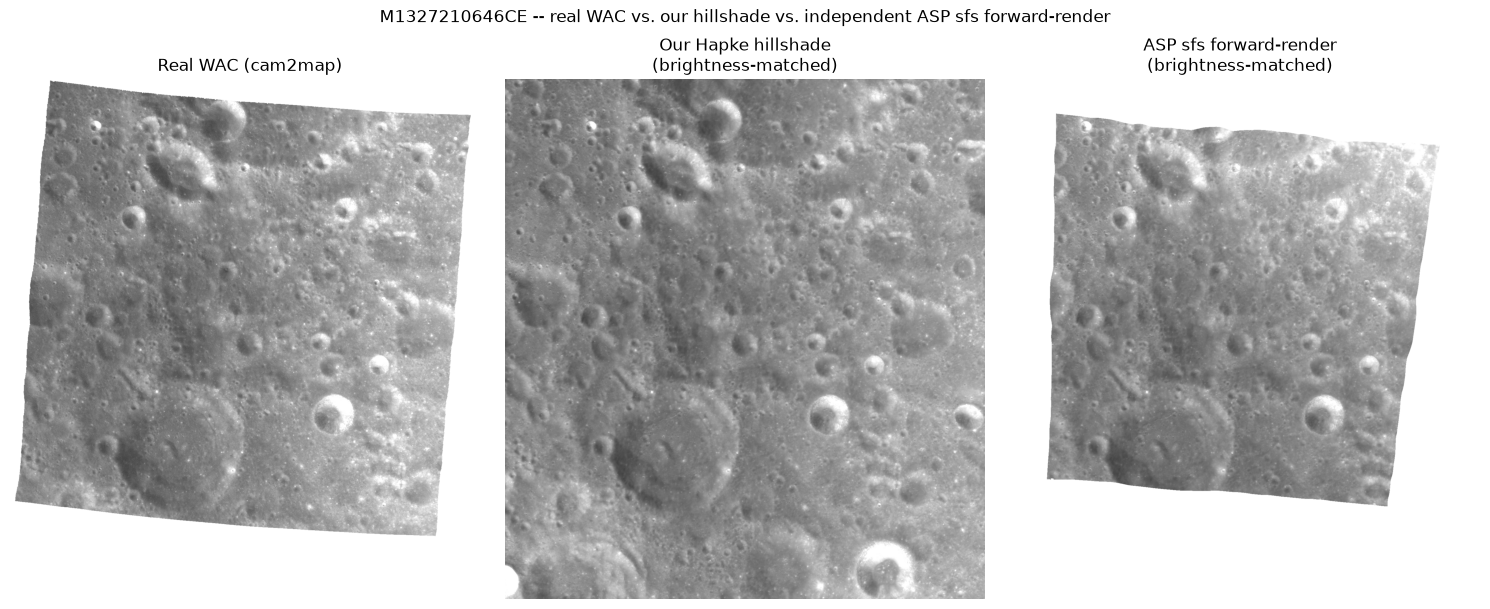

In [4]:
_ = plotting.plot_sfs_comparison(
    real_wac_mapproj_path,
    dem_ortho_result.ortho,
    sim_masked_path,
    title=f"{entry.edr_product} -- real WAC vs. our hillshade vs. independent ASP sfs forward-render",
)

## A cleaner cross-check: sfs's own incidence angle, via a Lambertian-mode trick

The Hapke comparison above is confounded by two caveats: the missing `theta` mapping, and
especially `sfs`'s reconstructed CSM camera having no way to represent `along_track_correction`.
Lambert's law has no emission or phase term at all -- just `image = exposure * albedo *
cos(incidence)` -- so running `sfs` with `--reflectance-type 0` and a uniform `albedo=1` makes its
raw `sim-intensity` output exactly `exposure * cos(incidence)`, letting us invert for `sfs`'s own
independently ray-traced incidence angle with **no Hapke-model dependence at all**. `exposure` isn't
`1.0` -- `sfs` applies some internal default scaling even without `--estimate-exposure-haze-albedo`
-- so `run_sfs_lambertian_incidence` reads it back from `sfs`'s own `<prefix>-exposures.txt` rather
than assuming it.

This is also this project's first **DEM-aware** ground-truth check -- no ISIS tool gives one:
`phocube`'s `LOCAL*` backplanes are broken, and `campt`'s angles stay ellipsoid-normal-based even
with a DEM shape model attached. Since incidence depends only on the surface normal and sun
direction (never the view vector), it's also unaffected by the along-track-correction gap that
limits the Hapke comparison above -- `along_track_correction` only ever changes emission/phase,
confirmed by comparing `lunaserv.real_geometry_photometric_angles` with it on vs. off (identical
incidence either way).

In [5]:
lambertian_result = sfs_validation.run_sfs_lambertian_incidence(camera, dem_ortho_result, config)
incidence_sfs_deg = sfs_validation.incidence_deg_from_lambertian_sim_intensity(
    lambertian_result.sim_intensity_tif, lambertian_result.exposure
)
print("sfs exposure:", lambertian_result.exposure)

sfs exposure: 113.18483749165841


In [6]:
with rasterio.open(dem_ortho_result.dem) as src:
    dem = src.read(1)

center = camera.footprint_lonlat_deg["center"]
azimuth_deg, elevation_deg = illumination.sun_azimuth_elevation_deg(*center, camera.et)
incidence_ours_deg, _emission_deg, _phase_deg = lunaserv.real_geometry_photometric_angles(
    dem, dem_ortho_result.bbox, camera, azimuth_deg, elevation_deg, config.dem_target_gsd_m
)

valid = np.isfinite(incidence_sfs_deg)
diff_deg = np.abs(incidence_sfs_deg[valid] - incidence_ours_deg[valid])
print(
    f"incidence diff over {valid.sum()} real-coverage pixels: "
    f"mean={diff_deg.mean():.4f} deg, max={diff_deg.max():.4f} deg"
)

incidence diff over 1618385 real-coverage pixels: mean=0.0005 deg, max=0.0005 deg


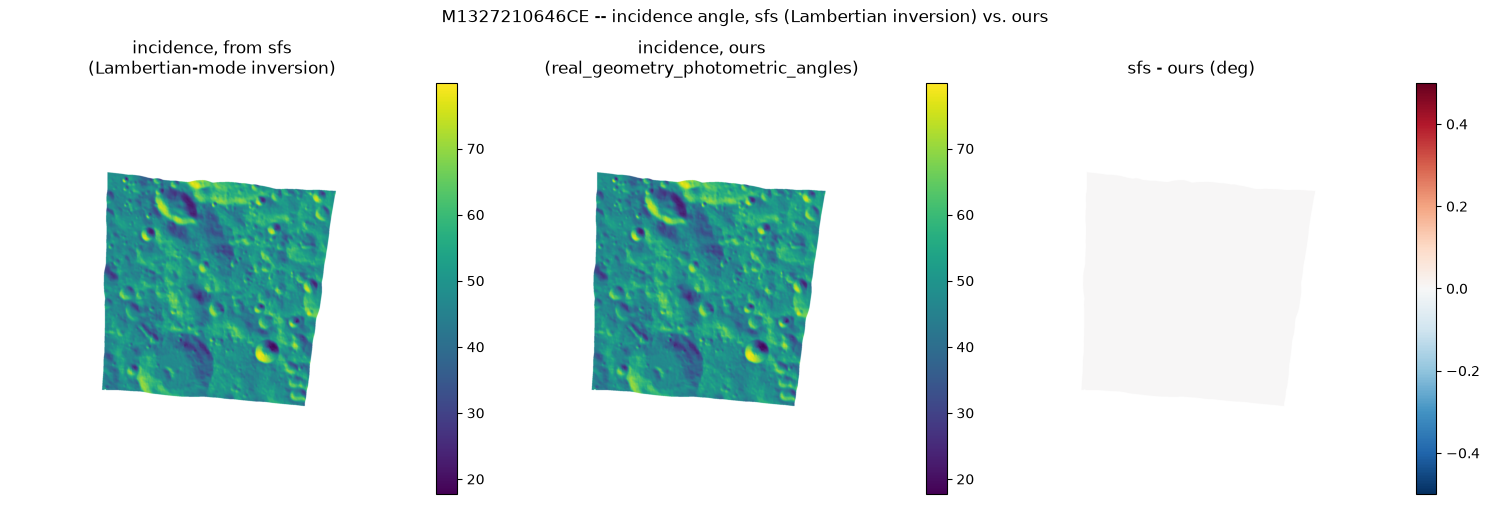

In [7]:
_ = plotting.plot_incidence_validation(
    incidence_sfs_deg,
    np.where(valid, incidence_ours_deg, np.nan),
    title=f"{entry.edr_product} -- incidence angle, sfs (Lambertian inversion) vs. ours",
)